In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np #võimaldab teha arvude jada, kasutan graafikus (np.arange(0, 0.5, 0.1))
from matplotlib.ticker import FormatStrFormatter #võimaldab telje numbrite vormindamist

In [3]:
df_rain = pd.read_csv("Tallinn-Harku-2004-2025_rain.csv")

PREPARE DATASET (no need to run these cells)

Laen andmed Exceli tabelitest "Tallinn-Harku-2004-2024" ja "Tallinn-Harku-2025". Kontrollin kas: veerunimed tabelites on samasugused --> parandasin; andmed sobivad --> OK (float, int). 

Liidan tabelid ja salvestan CSV formaati: "Tallinn-Harku-2004-2025_full.csv" kogu ühendatud algandmestik ja "Tallinn-Harku-2004-2025_rain.csv" kitsam tabel sademete anlüüsimiseks. Edasises töös laen andmed failist "Tallinn-Harku-2004-2025_rain.csv"

In [14]:
df_2024 = pd.read_excel("Tallinn-Harku-2004-2024.xlsx", header=2)
df_2025 = pd.read_excel("Tallinn-Harku-2025.xlsx", header=2)

In [ ]:
df_2024.columns.equals(df_2025.columns) 

In [ ]:
for col_2024, col_2025 in zip(df_2024.columns, df_2025.columns): 
    if col_2024 != col_2025:
        print("Erinevus:")
        print("df_2024:", repr(col_2024))
        print("df_2025:", repr(col_2025))
        print()

In [35]:
df_2025 = df_2025.rename(columns={
    "10 minuti keskmine tuule suund": "10 minuti keskmine tuule suund °"
})

In [ ]:
df_2024.dtypes

In [38]:
df_2004_2025 = pd.concat([df_2024, df_2025], ignore_index=True)

In [43]:
df_2004_2025.to_csv("Tallinn-Harku-2004-2025_full.csv", index=False)

In [44]:
cols = ["Aasta", "Kuu", "Päev", "Kell (UTC)", "Tunni sademete summa mm"]

df_rain = df_2004_2025[cols]
df_rain.to_csv("Tallinn-Harku-2004-2025_rain.csv", index=False)

BEFORE ANALYSIS - check missing values (no need to run these cells)

(Dataset: Tallinn-Harku-2004-2025_rain.csv).
Kontrollin NaN--> ainult sademete tulbas, muu OK. Täpsustan, millistes aastates ja kuudes NaN blokid asuvad--> juuni 2004-2025 andmed täielikud, saab kasutada Jaanipäeva analüüsis.

In [ ]:
df_rain.isna().sum() 

In [ ]:
nan_per_year = df_rain.groupby("Aasta")["Tunni sademete summa mm"].apply(lambda x: x.isna().sum())
nan_per_year = nan_per_year[nan_per_year > 0]
nan_per_year

In [23]:
#täpsustan, millistes aastates ja kuudes NaN blokid asuvad
df_temp = df_rain.copy()

df_temp["nan"] = df_temp["Tunni sademete summa mm"].isna() 

df_temp["group"] = (df_temp["nan"] != df_temp["nan"].shift()).cumsum() 

nan_info = df_temp[df_temp["nan"]].groupby("group").agg(
    start_year=("Aasta", "first"),
    start_month=("Kuu", "first"),
    end_year=("Aasta", "last"),
    end_month=("Kuu", "last"),
    length=("nan", "size")
) 

nan_info = nan_info.sort_values("length", ascending=False)
nan_info

,start_year,start_month,end_year,end_month,length
group,,,,,
1,2004,1,2004,4,2659
3,2005,1,2005,3,1392
7,2005,12,2006,2,998
15,2011,3,2011,3,13
5,2005,10,2005,10,8
17,2023,10,2023,10,5
9,2007,10,2007,10,1
11,2010,5,2010,5,1
13,2010,5,2010,5,1


BEFORE ANALYSIS - juuni andmete koondamine, 23. june overview, lävendite valik (run from here)

Võtan algtabelist (df_rain) juuni andmed. Koondan tunnipõhised sademete andmed ööpäevasteks summadeks. Iga rida on üks päev ühes aastas ja selle päeva kogusademed. Seda tabelit(june_daily) kasutan tõenäosuste arvutamiseks.

In [4]:
june_daily= (
    df_rain[df_rain["Kuu"] == 6]
    .groupby(["Aasta", "Päev"])["Tunni sademete summa mm"]
    .sum()
    .reset_index()
    .sort_values(["Päev", "Aasta"])
    .rename(columns={"Tunni sademete summa mm": "Ööpäeva sademete summa mm"})
)
june_daily.head()

,Aasta,Päev,Ööpäeva sademete summa mm
0,2004,1,0.0
30,2005,1,6.8
60,2006,1,0.6
90,2007,1,0.0
120,2008,1,0.0


Teen kiire kontrolli kuidas 23.juuni sademed aastate lõikes varieeruvad (2004-2025). Varieeruvus on suur. See aitab otsustada millised lävendid on mõtet valida edasiseks analüüsiks. Valin lävenditeks >0, >5, >10 mm 

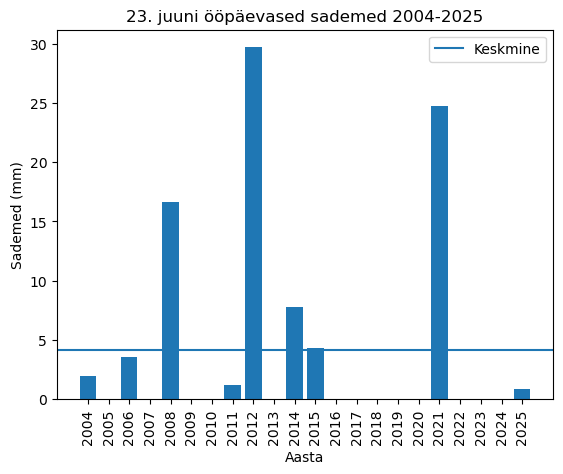

In [22]:
june23 = june_daily[june_daily["Päev"] == 23]

plt.figure()

plt.bar(june23["Aasta"], june23["Ööpäeva sademete summa mm"])

mean = june23["Ööpäeva sademete summa mm"].mean()
plt.axhline(mean, label="Keskmine")

plt.xticks(june23["Aasta"], rotation=90)

plt.xlabel("Aasta")
plt.ylabel("Sademed (mm)")
plt.title("23. juuni ööpäevased sademed 2004-2025")

plt.legend()
plt.show()

ANALYSIS - tõenäosus

Võtan kõik juuni päevad kokku (tabelist june_daily) ja arvutan sademete esinemise tõenäosuse valitud lävendite korral.
kogu valimi pealt (660 vaatlust). Iga lävendi puhul loendan, mitmel päeval ööpäeva sademete summa lävendit ületas, ning jagan selle kõigi juuni vaatluste arvuga.

Saan baastaseme (june_baseline_probability) ehk üldine tõenäosus kui valida suvaline juunipäev, arvestamata konkreetset kuupäeva. Seda kasutan võrdlusbaasina üksikute kuupäevade (nt jaanipäeva) analüüsimisel

In [5]:
thresholds = [0, 5, 10] 
rows = []

for x in thresholds:
    count_sademed = (june_daily["Ööpäeva sademete summa mm"] > x).sum()
    count_total = june_daily["Ööpäeva sademete summa mm"].count()
    probability = count_sademed / count_total
    
    rows.append({
        "lävend": x,
        "count_sademed": count_sademed,
        "count_total": count_total,
        "probability": probability
    })
    
june_baseline_probability = pd.DataFrame(rows) #teen rows listist dataframi df_probability
june_baseline_probability

,lävend,count_sademed,count_total,probability
0,0,244,660,0.369697
1,5,85,660,0.128788
2,10,42,660,0.063636


Arvutan iga juuni kuupäeva kohta sademete tõenäosuse valitud lävendite korral. Iga kuupäeva ja lävendi kombinatsiooni kohta loendan (tabelist june_daily), mitmel aastal ööpäeva sademete summa lävendit ületas, ning jagan selle olemasolevate vaatluste arvuga (22), saan tõenäosuse.

Tulemuseks on tabel (june_day_probability), kõigi juuni kuupäevade sademete tõenäosuse omavaheliseks võrdlemiseks. 

In [6]:
days = range(1, 31)
thresholds = [0, 5, 10] 
rows = [] #enne tsüklit teen listi tühjaks. Muidu salvestab juurde olnud infole.

for day in days:
    day_data = june_daily[june_daily["Päev"] == day] #võtab vastava kuupäeva andmed 

    for x in thresholds:
        count_sademed = (day_data["Ööpäeva sademete summa mm"] > x).sum()
        count_total = day_data["Ööpäeva sademete summa mm"].count()
    
        probability = count_sademed / count_total
    
        rows.append({
            "Päev": day,
            "lävend": x,
            "count_sademed": count_sademed,
            "count_total": count_total,
            "probability": probability
         }) #tekitab listi kombinatsioonidest päev,lävend, probability

june_day_probability = pd.DataFrame(rows) #teen rows listist dataframi df_probability
june_day_probability.head()

,Päev,lävend,count_sademed,count_total,probability
0,1,0,10,22,0.454545
1,1,5,2,22,0.090909
2,1,10,1,22,0.045455
3,2,0,7,22,0.318182
4,2,5,2,22,0.090909


GRAAFIKUD

Võtan (tabelist june_day_probability) välja 23. juuni ja teen tulpdiagrammi, millel võrdlen jaanipäeva 
ja suvalise juunipäeva (tabel june_baseline_probability) sademete tõenäosust.

Tulemus: jaanipäev on kõigi lävendite puhul natuke vihmasem kui suvaline juunipäev. Erinevus avaldub kõige rohkem lävendil >10 mm. 

In [11]:
june23_probability = june_day_probability[june_day_probability["Päev"] == 23] #võtan välja 23.juuni

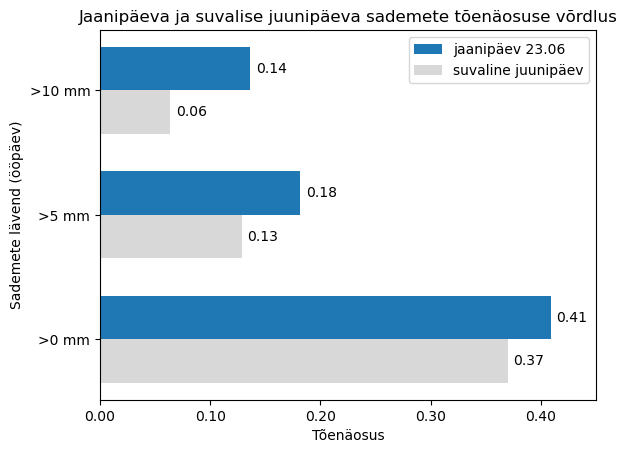

In [8]:
labels = [f">{x} mm" for x in june23_probability["lävend"]]

june23_vals = june23_probability["probability"].values
baseline_vals = june_baseline_probability["probability"].values

y = np.arange(len(labels))  # positsioonid
h = 0.35  # tulba kõrgus

plt.figure()

plt.barh(y + h/2, june23_vals, height=h, label="jaanipäev 23.06")
plt.barh(y - h/2, baseline_vals, height=h, label="suvaline juunipäev", color="gray", alpha=0.3)

for i, v in enumerate(june23_vals):
    plt.text(v+0.005, i + h/2, f"{v:.2f}", va="center")

for i, v in enumerate(baseline_vals):
    plt.text(v+0.005, i - h/2, f"{v:.2f}", va="center")

plt.xticks(np.arange(0, 0.5, 0.1)) #(alusta, lõpeta, samm). Kui tahad käsitsi kontrolli plt.xticks([0.2, 0.3, 0.4])
plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.xlim(0, 0.45)
plt.yticks(y, labels)

plt.xlabel("Tõenäosus")
plt.ylabel("Sademete lävend (ööpäev)")
plt.title("Jaanipäeva ja suvalise juunipäeva sademete tõenäosuse võrdlus")

plt.legend()

plt.show()

Koostan lävendi >10 mm jaoks punktdiagrammi, et  näha kuidas kõigi juuni kuupäevade sajutõenäosused baastaseme  (suvalise juunipäeva tõenäosus) ümber jaotuvad. Siis on näha, kas 23. juuni on erandlik või lihtsalt üks paljudest päevadest, mis kõiguvad ümber baastaseme.

Jaanipäev kuulub päevade hulka kus tugevama saju tõenäosus on veidi kõrgem, kuid ei paista selles grupis eriliselt silma.

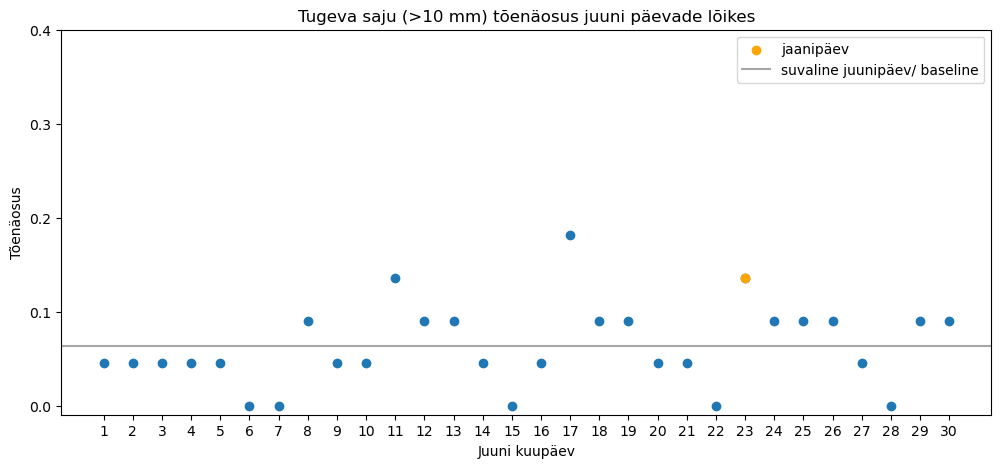

In [12]:
df_10 = june_day_probability[june_day_probability["lävend"] == 10]

# baseline väärtus (>10 mm)
baseline_10 = june_baseline_probability[
    june_baseline_probability["lävend"] == 10
]["probability"].values[0]

plt.figure(figsize=(12, 5)) #teeb graafiku laiemaks

plt.scatter(df_10["Päev"], df_10["probability"])

june23 = df_10[df_10["Päev"] == 23] 
plt.scatter(june23["Päev"], june23["probability"], color="orange", label="jaanipäev")

plt.xticks(np.arange(1, 31))
plt.yticks(np.arange(0, 0.5, 0.1))

plt.axhline(baseline_10, label="suvaline juunipäev/ baseline", color="gray", alpha=0.7) 

plt.xlabel("Juuni kuupäev")
plt.ylabel("Tõenäosus")
plt.title("Tugeva saju (>10 mm) tõenäosus juuni päevade lõikes")

plt.legend()

plt.show()